# Checkpoint Three: Cleaning Data

Now you are ready to clean your data. Before starting coding, provide the link to your dataset below.

My dataset:

Import the necessary libraries and create your dataframe(s).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Devin\OneDrive\Documents\Launchcode\python\data-analysis-projects\final-project\archive (2)\Impact_of_Remote_Work_on_Mental_Health.csv")

## Missing Data

Test your dataset for missing data and handle it as needed. Make notes in the form of code comments as to your thought process.

In [4]:
# first thing I need to do is check for nulls or Nan's
df.isnull().sum()
# The two columns that have missing data are Mental Health Conditions and Physical Activity, the next step will be determining what values that those columns consist of

Employee_ID                             0
Age                                     0
Gender                                  0
Job_Role                                0
Industry                                0
Years_of_Experience                     0
Work_Location                           0
Hours_Worked_Per_Week                   0
Number_of_Virtual_Meetings              0
Work_Life_Balance_Rating                0
Stress_Level                            0
Mental_Health_Condition              1196
Access_to_Mental_Health_Resources       0
Productivity_Change                     0
Social_Isolation_Rating                 0
Satisfaction_with_Remote_Work           0
Company_Support_for_Remote_Work         0
Physical_Activity                    1629
Sleep_Quality                           0
Region                                  0
dtype: int64

In [24]:
df['Mental_Health_Condition'].unique()
# In this set it looks like the 1196 values that where left as nan just stand for no condition, 
# Im going to check the the overall percentage of values in the mental health condition column then I will fill the NAN with "No condition" 
# Im doing this by initializing variables for each step
# First I am using a boolean to check whether my condition is true or false then counting all the instances of that boolean being true
# Then using the variable that the count is stored in divided by the count of all records in the column for the percentage of people that are affected by that condition

array(['Depression', 'Anxiety', 'No Condition', 'Burnout'], dtype=object)

In [26]:
Burnout_boolean = df['Mental_Health_Condition'] == 'Burnout'
Burnout_count = Burnout_boolean.loc[Burnout_boolean == True].count()
Burnout_Percentage = Burnout_count / df['Mental_Health_Condition'].count()
print(Burnout_Percentage.round(4))

0.256


In [27]:
Depression_boolean = df['Mental_Health_Condition'] == 'Depression'
Depression_count = Depression_boolean.loc[Depression_boolean == True].count()
Depression_Percentage = Depression_count / df['Mental_Health_Condition'].count()
print(Depression_Percentage.round(4))

0.2492


In [28]:
Anxiety_boolean = df['Mental_Health_Condition'] == 'Anxiety'
Anxiety_count = Anxiety_boolean.loc[Anxiety_boolean == True].count()
Anxiety_Percentage = Anxiety_count / df['Mental_Health_Condition'].count()
print(Anxiety_Percentage.round(4))

0.2556


In [29]:
df['Mental_Health_Condition'].fillna('No Condition', inplace=True) 
df['Mental_Health_Condition'].unique()
# Had to fill the values to get the correct percentages 

array(['Depression', 'Anxiety', 'No Condition', 'Burnout'], dtype=object)

In [31]:
df['Physical_Activity'].unique()
# doing the same thing for the physical activity column including changing the null values to represent the lack of physical activity

array(['Weekly', nan, 'Daily'], dtype=object)

In [34]:
Weekly_boolean = df['Physical_Activity'] == 'Weekly'
Weekly_count = Weekly_boolean.loc[Weekly_boolean == True].count()
Weekly_Percentage = Weekly_count / df['Physical_Activity'].count()
print(Weekly_Percentage.round(4))

0.351


In [35]:
Daily_boolean = df['Physical_Activity'] == 'Daily'
Daily_count = Daily_boolean.loc[Daily_boolean == True].count()
Daily_Percentage = Daily_count / df['Physical_Activity'].count()
print(Daily_Percentage.round(4))

0.3232


In [33]:
df['Physical_Activity'].fillna('No Activity', inplace=True)
df['Physical_Activity'].unique()

array(['Weekly', 'No Activity', 'Daily'], dtype=object)

In [36]:
no_activity_boolean = df['Physical_Activity'] == 'No Activity'
no_activity_count = no_activity_boolean.loc[no_activity_boolean == True].count()
no_activity_percentage = no_activity_count / df['Physical_Activity'].count()
print(no_activity_percentage.round(4))

0.3258


In [ ]:
# These percentages will likely be key in my manipulation to find out the main driving forces behind finding out trends between life style and work location

## Irregular Data

Detect outliers in your dataset and handle them as needed. Use code comments to make notes about your thought process.

In [37]:
df.head(10)
# using head to check the columns of the data set
# On the columns with larger sets of numbers than a rating I am running a value count, describe for the distribution and plotting a visualization
# to show the distribution such as histogram or box and whisker plot, for columns with 5 less unique values I am just using value counts to display their
# distribution

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,No Activity,Poor,North America
3,EMP0004,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,No Activity,Poor,Europe
4,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,No Condition,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America
5,EMP0006,59,Non-binary,Sales,IT,31,Hybrid,39,3,4,High,No Condition,No,Increase,5,Unsatisfied,1,No Activity,Average,South America
6,EMP0007,31,Prefer not to say,Sales,IT,24,Remote,51,7,3,Low,Anxiety,Yes,Decrease,5,Neutral,3,Daily,Poor,Asia
7,EMP0008,42,Non-binary,Data Scientist,Manufacturing,6,Onsite,54,7,3,Medium,Depression,No,Decrease,5,Satisfied,4,No Activity,Average,North America
8,EMP0009,56,Prefer not to say,Data Scientist,Healthcare,9,Hybrid,24,4,2,High,No Condition,Yes,Decrease,2,Unsatisfied,4,Daily,Poor,Europe
9,EMP0010,30,Female,HR,IT,28,Hybrid,57,6,1,Low,Depression,Yes,Decrease,2,Neutral,1,Weekly,Poor,North America


In [39]:
df['Age'].value_counts()

Age
53    152
45    149
25    145
23    142
24    138
50    138
58    138
47    138
43    137
56    136
48    136
40    135
42    135
57    135
32    133
30    133
36    132
49    132
28    131
22    131
39    130
27    129
51    129
52    125
60    125
41    124
31    124
46    121
34    120
59    119
33    119
35    119
38    115
37    112
29    112
55    112
44    111
26    109
54     99
Name: count, dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

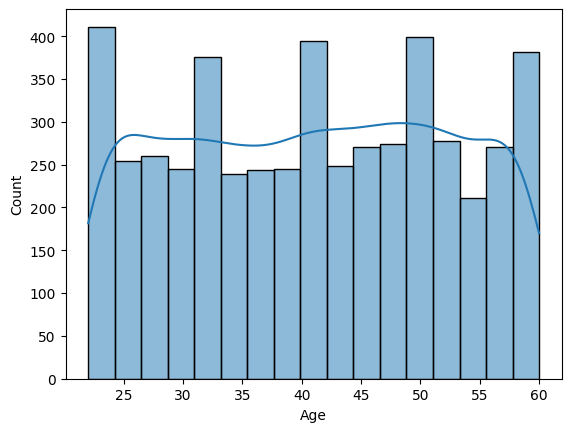

In [52]:
sns.histplot(df['Age'], kde=True)


In [53]:
df['Age'].describe()

count    5000.000000
mean       40.995000
std        11.296021
min        22.000000
25%        31.000000
50%        41.000000
75%        51.000000
max        60.000000
Name: Age, dtype: float64

In [59]:
df['Gender'].value_counts()

Gender
Female               1274
Male                 1270
Prefer not to say    1242
Non-binary           1214
Name: count, dtype: int64

In [57]:
df['Job_Role'].value_counts()

Job_Role
Project Manager      738
Sales                733
Designer             723
HR                   716
Software Engineer    711
Data Scientist       696
Marketing            683
Name: count, dtype: int64

In [58]:
df['Industry'].value_counts()

Industry
Finance          747
IT               746
Healthcare       728
Retail           726
Education        690
Manufacturing    683
Consulting       680
Name: count, dtype: int64

In [61]:
df['Years_of_Experience'].value_counts()

Years_of_Experience
23    171
26    168
6     159
9     159
29    157
13    157
7     157
3     156
10    155
21    155
30    153
12    151
4     148
14    148
25    148
18    146
33    146
22    143
1     142
20    137
19    137
34    137
24    135
16    134
31    133
8     133
2     133
5     131
27    130
17    128
28    128
11    126
32    125
15    122
35    112
Name: count, dtype: int64

In [64]:
df['Years_of_Experience'].describe()

count    5000.000000
mean       17.810200
std        10.020412
min         1.000000
25%         9.000000
50%        18.000000
75%        26.000000
max        35.000000
Name: Years_of_Experience, dtype: float64

<Axes: xlabel='Years_of_Experience', ylabel='Count'>

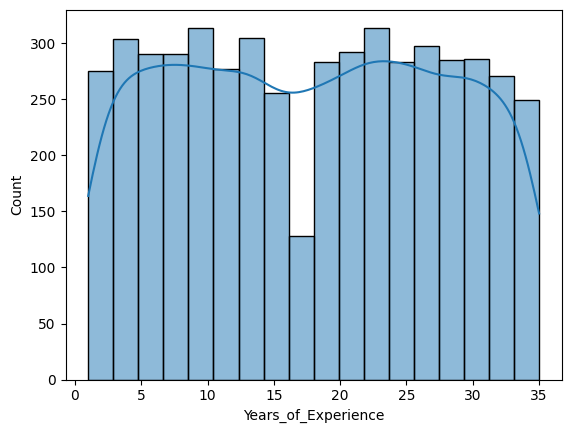

In [83]:
sns.histplot(df['Years_of_Experience'], kde=True)

In [69]:
df['Work_Location'].value_counts()

Work_Location
Remote    1714
Hybrid    1649
Onsite    1637
Name: count, dtype: int64

In [70]:
df['Hours_Worked_Per_Week'].value_counts()

Hours_Worked_Per_Week
28    149
22    142
20    137
32    136
33    135
41    133
49    129
25    129
36    128
23    128
27    127
53    127
45    125
24    125
48    123
59    123
57    123
31    122
56    122
35    122
21    121
46    121
39    121
50    120
42    120
40    120
44    119
54    119
47    119
37    116
43    115
55    115
34    113
29    113
60    112
38    112
26    112
52    111
30    108
51    104
58    104
Name: count, dtype: int64

In [71]:
df['Hours_Worked_Per_Week'].describe()

count    5000.000000
mean       39.614600
std        11.860194
min        20.000000
25%        29.000000
50%        40.000000
75%        50.000000
max        60.000000
Name: Hours_Worked_Per_Week, dtype: float64

<Axes: xlabel='Hours_Worked_Per_Week'>

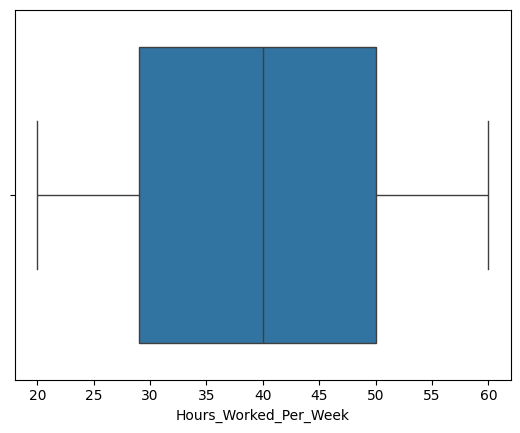

In [72]:
sns.boxplot(x=df['Hours_Worked_Per_Week'])

In [73]:
df['Number_of_Virtual_Meetings'].value_counts()

Number_of_Virtual_Meetings
15    347
7     329
10    328
0     327
9     324
2     320
8     316
12    315
14    311
4     306
5     303
13    301
3     297
1     294
11    292
6     290
Name: count, dtype: int64

In [74]:
df['Number_of_Virtual_Meetings'].describe()

count    5000.000000
mean        7.559000
std         4.636121
min         0.000000
25%         4.000000
50%         8.000000
75%        12.000000
max        15.000000
Name: Number_of_Virtual_Meetings, dtype: float64

In [75]:
df['Work_Life_Balance_Rating'].value_counts()

Work_Life_Balance_Rating
3    1053
1    1023
4     980
5     977
2     967
Name: count, dtype: int64

In [76]:
df['Stress_Level'].value_counts()

Stress_Level
High      1686
Medium    1669
Low       1645
Name: count, dtype: int64

In [77]:
df['Access_to_Mental_Health_Resources'].value_counts()

Access_to_Mental_Health_Resources
No     2553
Yes    2447
Name: count, dtype: int64

In [78]:
df['Productivity_Change'].value_counts()

Productivity_Change
Decrease     1737
No Change    1677
Increase     1586
Name: count, dtype: int64

In [79]:
df['Social_Isolation_Rating'].value_counts()

Social_Isolation_Rating
2    1066
4    1037
3     992
1     953
5     952
Name: count, dtype: int64

In [80]:
df['Satisfaction_with_Remote_Work'].value_counts()

Satisfaction_with_Remote_Work
Unsatisfied    1677
Satisfied      1675
Neutral        1648
Name: count, dtype: int64

In [81]:
df['Company_Support_for_Remote_Work'].value_counts()

Company_Support_for_Remote_Work
3    1077
5     987
2     985
4     984
1     967
Name: count, dtype: int64

In [82]:
df['Sleep_Quality'].value_counts()

Sleep_Quality
Good       1687
Poor       1685
Average    1628
Name: count, dtype: int64

In [66]:
df['Region'].value_counts()

Region
Oceania          867
Africa           860
Europe           840
Asia             829
South America    827
North America    777
Name: count, dtype: int64

In [ ]:
# One thing that I will continue to note is the symmetry of this data set, essentially all the columns are evenly distributed. That being said I did
# not find any outliers to investigate, this data set was described as very clean and that has held up so far.

## Unnecessary Data

Look for the different types of unnecessary data in your dataset and address it as needed. Make sure to use code comments to illustrate your thought process.

In [65]:
df.head()
# checking the columns to see what I do not need. 

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,No Activity,Poor,North America
3,EMP0004,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,No Activity,Poor,Europe
4,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,No Condition,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [68]:
# I am choosing to not explore the differences between gender in this particular analysis
# Part of the reason being that gender had 25% of respondants choose not to disclose their gender
df = df.drop(['Gender'], axis=1)



## Inconsistent Data

Check for inconsistent data and address any that arises. As always, use code comments to illustrate your thought process.

In [ ]:
# From earlier when I ran all the value counts to see the distribution and responses everything was very balanced and evenly distributed 
# From what I saw I did not have any inconsistent data 

## Summarize Your Results

Make note of your answers to the following questions.

1. Did you find all four types of dirty data in your dataset?
2. Did the process of cleaning your data give you new insights into your dataset?
3. Is there anything you would like to make note of when it comes to manipulating the data and making visualizations?

1. I only found 2 of the 4 types of dirty data, by running all the value counts I found that this set was pretty devoid of outliers so I did not find much in terms of Inconsistent or Irregular Data. Deciding what I did not want to include in the analysis was key and I decided the only category that I was not interested in looking at was gender and that was partially due to 25% of the respondents choosing not to disclose their gender. I was close to dropping region as well but decided that it may be worthwhile to group the responses by region and see if there is a pattern. For missing data I chose to fill in the NAs, they seemed to represent the lack of exercise and the lack of a mental health issue when I was examining the data set during EDA.
2. It did give me some new insights, for example it made me realise that I would very much have enjoyed a column where the respondents told how long they had been working remote or hybrid for. Again I will note the overall symmetry of the data set. I hope when I begin doing a lot of grouping that I can discover some skews.
3. Mainly that I think the major trends are going to come from people who lack substance outside of their work lives are going to be the ones most prone for mental health issues. 